# Bloodborne Weapon and Boss EDA

Exploratory data analysis on Bloodborne trick weapons, firearms, and boss data, ahead of analyzing which damage type has the best average coverage against bosses

In [236]:
import pandas as pd  # for data manipulation
import matplotlib.pyplot as plt  # for data visualization

## Load the Data

In [237]:
# Load raw CSVs from the data folder
trick_weapons = pd.read_csv('../data/trick_weapons.csv')
firearms = pd.read_csv('../data/firearm_weapons.csv')
bosses = pd.read_csv('../data/bosses.csv')

## Initial look at each table

In [238]:
trick_weapons.head()  # preview first 5 rows of trick weapons

,trick_wpn_id,name,physical_atk,blood_atk,arcane_atk,fire_atk,bolt_atk,slow_poison,rapid_poison,vs_kin,...,bloodtinge_scl,arcane_req,arcane_scl,durability,qs_bullet,rally,normal,uncanny,lost,location
0,1,Amygdalan Arm,80.0,NaN,40.0,NaN,NaN,NaN,NaN,100,...,NaN,NaN,D,200,NaN,NaN,NaN,NaN,NaN,"The Hunter's Nightmare, cave to the right afte..."
1,2,Beast Claw,75.0,NaN,NaN,NaN,NaN,NaN,NaN,100,...,NaN,NaN,D,180,NaN,NaN,NaN,NaN,NaN,Ailing Loran Chalice
2,3,Beast Cutter,92.0,NaN,NaN,NaN,NaN,NaN,NaN,100,...,NaN,NaN,E,230,NaN,NaN,NaN,NaN,NaN,Walking down the stairs from the Nightmare Cat...
3,4,Beasthunter Saif,90.0,NaN,NaN,NaN,NaN,NaN,NaN,100,...,NaN,NaN,D,200,NaN,NaN,NaN,NaN,NaN,The Hunter's Nightmare. Area to after passing ...
4,5,Blade of Mercy,60.0,NaN,30.0,NaN,NaN,NaN,NaN,100,...,NaN,NaN,D,200,NaN,30.0,NaN,NaN,NaN,"Can be purchased from the Messengers for 40,00..."


In [239]:
firearms.head() # preview first 5 rows of firearms

,firearm_wpn_id,name,physical_atk,blood_atk,arcane_atk,fire_atk,bolt_atk,slow_poison,rapid_poison,vs_kin,...,skill_req,skill_scl,bloodtinge_req,bloodtinge_scale,arcane_req,arcane_scl,durability,qs_bullet,socket,location
0,1,Cannon,NaN,200.0,NaN,NaN,NaN,NaN,NaN,100,...,13.0,NaN,NaN,E,NaN,NaN,200,12.0,NaN,Found in the rafters of a building inside the ...
1,2,Church Cannon,NaN,160.0,NaN,NaN,NaN,NaN,NaN,100,...,NaN,NaN,16.0,E,NaN,NaN,200,10.0,NaN,Found after activating the altar elevator to t...
2,3,Evelyn,NaN,60.0,NaN,NaN,NaN,NaN,NaN,100,...,11.0,NaN,18.0,B,NaN,NaN,100,1.0,NaN,Can be purchased from the Messengers for 16000...
3,4,Fist of Gratia,60.0,NaN,NaN,NaN,NaN,NaN,NaN,100,...,9.0,NaN,5.0,NaN,NaN,NaN,200,NaN,NaN,"In The Hunter's Nightmare, locked inside one o..."
4,5,Flamesprayer,NaN,NaN,NaN,45.0,NaN,NaN,NaN,100,...,8.0,NaN,NaN,NaN,8\n\nD,NaN,100,1.0,NaN,Acquired from Gilbert after entering the Cathe...


In [240]:
bosses.head()  # preview first 5 rows of bosses

,boss_id,name,location,hp,is_optional,is_dlc,is_beast,is_kin,def_phys,def_blunt,def_thrust,def_blood,def_arcane,def_fire,def_bolt,res_slow_poison,res_rapid_poison
0,1,Cleric Beast,Central Yharnam,3015,True,False,Yes,No,103,123,103,103,165,50,165,999,999
1,2,Father Gascoigne,Central Yharnam,2031,False,False,No/Yes,No/No,126,126,126,126,160,65,120,999,999
2,3,Vicar Amelia,Cathedral Ward,5367,False,False,Yes,No,113,135,113,113,160,55,160,999,999
3,4,Celestial Emissary,Upper Cathedral,2764,True,False,No,Yes,235,261,26,131,170,60,55,300,180
4,5,"Ebrietas, Daughter of the Cosmos",Altar of Despair,12493,True,False,No,Yes,252,336,101,168,170,60,55,999,999


## Structure check: rows, columns, data types, non-null counts

In [241]:
trick_weapons.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   trick_wpn_id    26 non-null     int64  
 1   name            26 non-null     str    
 2   physical_atk    25 non-null     float64
 3   blood_atk       5 non-null      float64
 4   arcane_atk      6 non-null      float64
 5   fire_atk        1 non-null      float64
 6   bolt_atk        1 non-null      float64
 7   slow_poison     0 non-null      float64
 8   rapid_poison    1 non-null      float64
 9   vs_kin          26 non-null     int64  
 10  vs_beasts       26 non-null     int64  
 11  strength_req    25 non-null     float64
 12  strength_scl    22 non-null     str    
 13  skill_req       25 non-null     float64
 14  skill_scl       23 non-null     str    
 15  bloodtinge_req  5 non-null      float64
 16  bloodtinge_scl  5 non-null      str    
 17  arcane_req      4 non-null      float64
 18  arc

In [242]:
firearms.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   firearm_wpn_id    16 non-null     int64  
 1   name              16 non-null     str    
 2   physical_atk      1 non-null      float64
 3   blood_atk         9 non-null      float64
 4   arcane_atk        1 non-null      float64
 5   fire_atk          3 non-null      float64
 6   bolt_atk          0 non-null      float64
 7   slow_poison       0 non-null      float64
 8   rapid_poison      0 non-null      float64
 9   vs_kin            16 non-null     int64  
 10  vs_beasts         16 non-null     int64  
 11  strength_req      14 non-null     float64
 12  strength_scl      1 non-null      str    
 13  skill_req         13 non-null     float64
 14  skill_scl         0 non-null      float64
 15  bloodtinge_req    8 non-null      float64
 16  bloodtinge_scale  9 non-null      str    
 17  arcane_req

In [243]:
bosses.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   boss_id           22 non-null     int64
 1   name              22 non-null     str  
 2   location          22 non-null     str  
 3   hp                22 non-null     int64
 4   is_optional       22 non-null     bool 
 5   is_dlc            22 non-null     bool 
 6   is_beast          22 non-null     str  
 7   is_kin            22 non-null     str  
 8   def_phys          22 non-null     int64
 9   def_blunt         22 non-null     int64
 10  def_thrust        22 non-null     int64
 11  def_blood         22 non-null     int64
 12  def_arcane        22 non-null     int64
 13  def_fire          22 non-null     int64
 14  def_bolt          22 non-null     int64
 15  res_slow_poison   22 non-null     int64
 16  res_rapid_poison  22 non-null     int64
dtypes: bool(2), int64(11), str(4)
memory usage: 2.8 

## Check for missing values (exact counts per column)

In [244]:
trick_weapons.isnull().sum()

trick_wpn_id       0
name               0
physical_atk       1
blood_atk         21
arcane_atk        20
fire_atk          25
bolt_atk          25
slow_poison       26
rapid_poison      25
vs_kin             0
vs_beasts          0
strength_req       1
strength_scl       4
skill_req          1
skill_scl          3
bloodtinge_req    21
bloodtinge_scl    21
arcane_req        22
arcane_scl         0
durability         0
qs_bullet         22
rally             13
normal            26
uncanny           26
lost              26
location           0
dtype: int64

In [245]:
firearms.isnull().sum()

firearm_wpn_id       0
name                 0
physical_atk        15
blood_atk            7
arcane_atk          15
fire_atk            13
bolt_atk            16
slow_poison         16
rapid_poison        16
vs_kin               0
vs_beasts            0
strength_req         2
strength_scl        15
skill_req            3
skill_scl           16
bloodtinge_req       8
bloodtinge_scale     7
arcane_req          12
arcane_scl          16
durability           0
qs_bullet            5
socket              16
location             0
dtype: int64

In [246]:
bosses.isnull().sum()

boss_id             0
name                0
location            0
hp                  0
is_optional         0
is_dlc              0
is_beast            0
is_kin              0
def_phys            0
def_blunt           0
def_thrust          0
def_blood           0
def_arcane          0
def_fire            0
def_bolt            0
res_slow_poison     0
res_rapid_poison    0
dtype: int64

## Summary statistics for numeric columns

In [247]:
trick_weapons.describe()

,trick_wpn_id,physical_atk,blood_atk,arcane_atk,fire_atk,bolt_atk,slow_poison,rapid_poison,vs_kin,vs_beasts,strength_req,skill_req,bloodtinge_req,arcane_req,durability,qs_bullet,rally,normal,uncanny,lost
count,26.000000,25.000000,5.000000,6.000000,1.0,1.0,0.0,1.0,26.0,26.0,25.00000,25.000000,5.000000,4.000000,26.000000,4.00,13.000000,0.0,0.0,0.0
mean,13.500000,86.600000,84.400000,34.166667,60.0,40.0,NaN,30.0,100.0,100.0,11.92000,10.840000,11.200000,11.000000,216.153846,1.25,43.076923,NaN,NaN,NaN
std,7.648529,9.725396,7.021396,9.174239,NaN,NaN,NaN,NaN,0.0,0.0,4.01995,2.995552,2.949576,8.406347,93.726279,0.50,13.622662,NaN,NaN,NaN
min,1.000000,60.000000,75.000000,25.000000,60.0,40.0,NaN,30.0,100.0,100.0,7.00000,6.000000,9.000000,0.000000,100.000000,1.00,30.000000,NaN,NaN,NaN
25%,7.250000,80.000000,80.000000,30.000000,60.0,40.0,NaN,30.0,100.0,100.0,9.00000,9.000000,9.000000,7.500000,185.000000,1.00,35.000000,NaN,NaN,NaN
50%,13.500000,88.000000,85.000000,30.000000,60.0,40.0,NaN,30.0,100.0,100.0,10.00000,11.000000,10.000000,12.000000,200.000000,1.00,40.000000,NaN,NaN,NaN
75%,19.750000,92.000000,90.000000,37.500000,60.0,40.0,NaN,30.0,100.0,100.0,16.00000,12.000000,12.000000,15.500000,250.000000,1.25,45.000000,NaN,NaN,NaN
max,26.000000,105.000000,92.000000,50.000000,60.0,40.0,NaN,30.0,100.0,100.0,20.00000,20.000000,16.000000,20.000000,600.000000,2.00,75.000000,NaN,NaN,NaN


In [248]:
firearms.describe()

,firearm_wpn_id,physical_atk,blood_atk,arcane_atk,fire_atk,bolt_atk,slow_poison,rapid_poison,vs_kin,vs_beasts,strength_req,skill_req,skill_scl,bloodtinge_req,arcane_scl,durability,qs_bullet,socket
count,16.000000,1.0,9.000000,1.0,3.000000,0.0,0.0,0.0,16.0,16.0,14.000000,13.000000,0.0,8.000000,0.0,16.000,11.000000,0.0
mean,8.500000,60.0,86.666667,30.0,40.000000,NaN,NaN,NaN,100.0,100.0,12.428571,9.692308,NaN,9.375000,NaN,140.625,2.909091,NaN
std,4.760952,NaN,59.371710,NaN,13.228757,NaN,NaN,NaN,0.0,0.0,8.759296,1.652504,NaN,5.040904,NaN,42.500,4.036200,NaN
min,1.000000,60.0,20.000000,30.0,25.000000,NaN,NaN,NaN,100.0,100.0,6.000000,8.000000,NaN,5.000000,NaN,80.000,1.000000,NaN
25%,4.750000,60.0,60.000000,30.0,35.000000,NaN,NaN,NaN,100.0,100.0,7.000000,8.000000,NaN,5.000000,NaN,100.000,1.000000,NaN
50%,8.500000,60.0,80.000000,30.0,45.000000,NaN,NaN,NaN,100.0,100.0,9.000000,9.000000,NaN,8.500000,NaN,145.000,1.000000,NaN
75%,12.250000,60.0,90.000000,30.0,47.500000,NaN,NaN,NaN,100.0,100.0,10.750000,11.000000,NaN,10.750000,NaN,170.000,1.500000,NaN
max,16.000000,60.0,200.000000,30.0,50.000000,NaN,NaN,NaN,100.0,100.0,30.000000,13.000000,NaN,18.000000,NaN,200.000,12.000000,NaN


In [249]:
bosses.describe()

,boss_id,hp,def_phys,def_blunt,def_thrust,def_blood,def_arcane,def_fire,def_bolt,res_slow_poison,res_rapid_poison
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,11.500000,9329.227273,146.000000,159.000000,121.409091,134.818182,161.454545,120.727273,123.181818,787.636364,736.227273
std,6.493587,6296.538837,45.727974,60.290566,31.679435,26.947279,78.068180,145.324328,67.835681,354.265779,393.831355
min,1.000000,2031.000000,79.000000,79.000000,26.000000,79.000000,65.000000,50.000000,40.000000,144.000000,132.000000
25%,6.250000,3871.750000,121.500000,130.750000,104.250000,121.500000,76.250000,66.250000,70.250000,474.750000,180.000000
50%,11.500000,7656.500000,136.000000,142.000000,127.000000,134.000000,160.000000,74.000000,111.500000,999.000000,999.000000
75%,16.750000,14081.000000,149.500000,173.250000,139.250000,148.000000,224.000000,114.250000,163.750000,999.000000,999.000000
max,22.000000,21242.000000,252.000000,336.000000,183.000000,183.000000,290.000000,744.000000,300.000000,999.000000,999.000000


## Drop unnecessary columns

In [250]:
# Drop columns not needed for this analysis
trick_weapons = trick_weapons.drop(columns=['normal', 'uncanny', 'lost', 'location', 'vs_kin', 'vs_beasts'])
firearms = firearms.drop(columns = ['socket', 'location', 'vs_kin', 'vs_beasts'])
bosses = bosses.drop(columns = ['location', 'is_optional'])

In [251]:
firearms['arcane_req'].unique()  # see all distinct values in this column

<StringArray>
[nan, '8\n\nD', '-\n\nB', '8\n\nB', '-\n\nD']
Length: 5, dtype: str

## Fix combined arcane requirement and scaling columns

This column pair was missed during an earlier Google Sheets cleanup - the wiki stacked the requirement and scaling letter with a line break instead of separating them, which wasn't visible until checked with '.unique".

In [252]:
firearms['arcane_scl'] = firearms['arcane_req'].str.extract(r'([A-Z])')  # populate arcane_scl column with scaling letter from arcane_req
firearms['arcane_req'] = firearms['arcane_req'].str.extract(r'(\d+)').astype(float)  # update arcane_req column to only contain the numeric required attribute
firearms[['arcane_scl', 'arcane_req']].head(10)  # Display first 10 rows of the updated columns


,arcane_scl,arcane_req
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,D,8.0
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,B,NaN
9,NaN,NaN


## Fill all NaN rows in attack and attribute requirement columns with 0

Since "0 damage/0 required" is factually what the Bloodborne's stat system means with a blank value, I replaced these values with 0.

In [253]:
# Attribute requirements
req_cols = ['strength_req', 'skill_req', 'bloodtinge_req', 'arcane_req']
trick_weapons[req_cols] = trick_weapons[req_cols].fillna(0)
firearms[req_cols] = firearms[req_cols].fillna(0)

# Attack
atk_cols = ['physical_atk', 'blood_atk', 'arcane_atk', 'fire_atk', 'bolt_atk']
trick_weapons[atk_cols] = trick_weapons[atk_cols].fillna(0)
firearms[atk_cols] = firearms[atk_cols].fillna(0)

# Poison
poison_cols = ['slow_poison', 'rapid_poison']
trick_weapons[poison_cols] = trick_weapons[poison_cols].fillna(0)
firearms[poison_cols] = firearms[poison_cols].fillna(0)

# Quicksilver bullets
trick_weapons['qs_bullet'] = trick_weapons['qs_bullet'].fillna(0)
firearms['qs_bullet'] = firearms['qs_bullet'].fillna(0)

## Re-check columns after fixes

Since fillna(0) removed NaNs from various columns, I confirmed that there were no nulls existing in them.

In [254]:
trick_weapons.isnull().sum()

trick_wpn_id       0
name               0
physical_atk       0
blood_atk          0
arcane_atk         0
fire_atk           0
bolt_atk           0
slow_poison        0
rapid_poison       0
strength_req       0
strength_scl       4
skill_req          0
skill_scl          3
bloodtinge_req     0
bloodtinge_scl    21
arcane_req         0
arcane_scl         0
durability         0
qs_bullet          0
rally             13
dtype: int64

In [255]:
firearms.isnull().sum()

firearm_wpn_id       0
name                 0
physical_atk         0
blood_atk            0
arcane_atk           0
fire_atk             0
bolt_atk             0
slow_poison          0
rapid_poison         0
strength_req         0
strength_scl        15
skill_req            0
skill_scl           16
bloodtinge_req       0
bloodtinge_scale     7
arcane_req           0
arcane_scl          12
durability           0
qs_bullet            0
dtype: int64

## Save cleaned CSVS

Export cleaned datasets without index numbers as CSV files for further analysis in SQL

In [256]:
trick_weapons.to_csv('../data/trick_weapons_cleaned.csv', index=False)
firearms.to_csv('../data/firearm_weapons_cleaned.csv', index=False)

## Reshape trick weapons from wide to long format
By using .melt(), I organized the damage columns into rows (one row per weapon-damage_type pair)

In [257]:
# Organize damage columns into a list
damage_cols = ['physical_atk', 'blood_atk', 'arcane_atk', 'fire_atk', 'bolt_atk', 'slow_poison', 'rapid_poison']

trick_long = trick_weapons.melt(
    id_vars = ['trick_wpn_id', 'name'],
    value_vars=damage_cols,
    var_name='damage_type',
    value_name='attack_value'
)

# Filter out rows where attack_value is 0
trick_long = trick_long[trick_long['attack_value'] > 0]

## Retrieve the average attack value per damage type

In [258]:
trick_long.groupby('damage_type')['attack_value'].mean()
trick_long['damage_type'].value_counts()

damage_type
physical_atk    25
arcane_atk       6
blood_atk        5
fire_atk         1
bolt_atk         1
rapid_poison     1
Name: count, dtype: int64

## Do the same for firearms

In [259]:
firearms_long = firearms.melt(
    id_vars = ['firearm_wpn_id', 'name'],
    value_vars=damage_cols,
    var_name='damage_type',
    value_name='attack_value'
)

firearms_long = firearms_long[firearms_long['attack_value'] > 0]

In [260]:
firearms_long.groupby('damage_type')['attack_value'].mean()
firearms_long['damage_type'].value_counts()

damage_type
blood_atk       9
fire_atk        3
physical_atk    1
arcane_atk      1
Name: count, dtype: int64

## Reshape bosses from wide to long format

Many bosses hold 999 as sentinel values for their poison resistance column, meaning that they are immune to poison. Bosses that are resistant to poison will have poison resistance rows omitted from the long table.

In [261]:
def_cols = ['def_phys', 'def_blunt', 'def_thrust', 'def_blood', 'def_arcane', 'def_fire', 'def_bolt', 'res_slow_poison', 'res_rapid_poison']

bosses_long = bosses.melt(
    id_vars = ['boss_id', 'name'],
    value_vars = def_cols,
    var_name = 'defense_type',
    value_name = 'defense_value'
)

bosses_long = bosses_long[bosses_long['defense_value'] < 999]
bosses_long = bosses_long.sort_values(['name', 'defense_value'])

In [262]:
bosses_long.groupby('name')['defense_value'].mean()
bosses_long['defense_type'].value_counts()

defense_type
def_arcane          22
def_fire            22
def_bolt            22
def_phys            22
def_thrust          22
def_blood           22
def_blunt           22
res_rapid_poison     7
res_slow_poison      6
Name: count, dtype: int64

## Export long-format tables to hand off in SQL

In [263]:
trick_long.to_csv('../data/trick_weapons_long.csv', index=False)
firearms_long.to_csv('../data/firearms_long.csv', index=False)
bosses_long.to_csv('../data/bosses_long.csv', index=False)

## Check which letter grade is most common among scaling types

Bloodborne's scaling system starts from S (best) and ends at E (worst). Some weapons may not scale with an attribute at all. I ordered it this way to see which scaling type has the best potential for upgrading.

In [264]:
grade_order = ['S', 'A', 'B', 'C', 'D', 'E']
trick_weapons['strength_scl'].value_counts().reindex(grade_order).fillna(0)

strength_scl
S    0.0
A    0.0
B    1.0
C    5.0
D    9.0
E    7.0
Name: count, dtype: float64

In [265]:
trick_weapons['skill_scl'].value_counts().reindex(grade_order).fillna(0)

skill_scl
S    0.0
A    0.0
B    0.0
C    6.0
D    8.0
E    9.0
Name: count, dtype: float64

In [266]:
trick_weapons['bloodtinge_scl'].value_counts().reindex(grade_order).fillna(0)

bloodtinge_scl
S    0.0
A    0.0
B    1.0
C    2.0
D    1.0
E    1.0
Name: count, dtype: float64

In [267]:
trick_weapons['arcane_scl'].value_counts().reindex(grade_order).fillna(0)

arcane_scl
S     0.0
A     1.0
B     0.0
C     1.0
D    23.0
E     1.0
Name: count, dtype: float64

## Basic Visual Check
I created a bar chart of average requirement value per scaling type check for any patterns before analysis with SQL. The chart shows that trick weapons prioritize scaling with strength and skill.

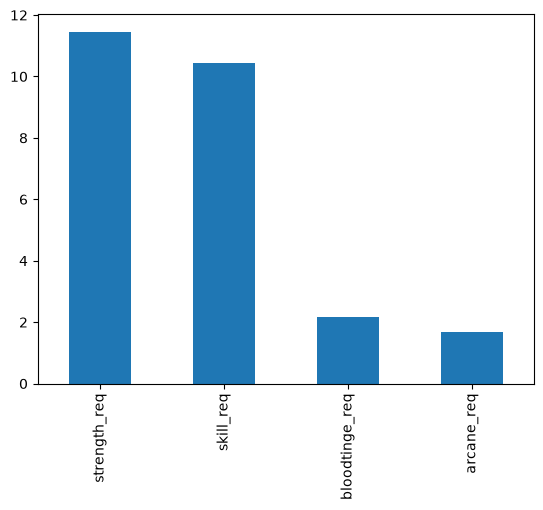

In [268]:
trick_weapons[req_cols].mean().plot(kind='bar')
plt.show()

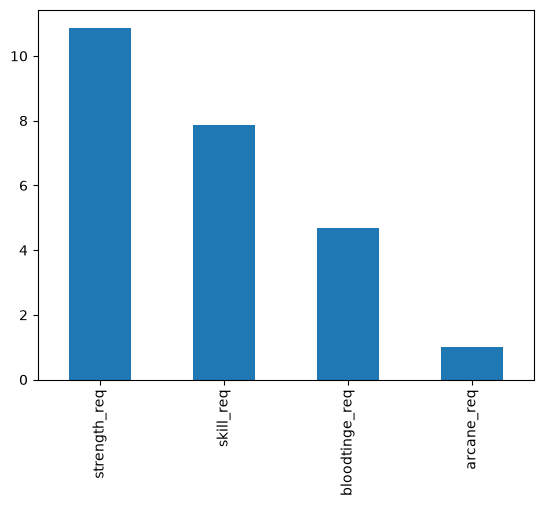

In [269]:
firearms[req_cols].mean().plot(kind='bar')
plt.show()